In [1]:
import pandas as pd

df = pd.read_csv("HR-Employee-Attrition.csv")

print(df.head())
print(df.info())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  TrainingTimesLastYear WorkLifeBalance  YearsAtCompany  \
0  ...   

In [2]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [3]:
df['burnout_score'] = (
    0.3 * df['work_hours_per_week'] +
    0.25 * df['meetings_per_week'] +
    0.2 * df['leave_days_last_3_months'] +
    0.25 * (10 - df['engagement_score'])
)

In [4]:
df['burnout_score'] = 100 * (df['burnout_score'] - df['burnout_score'].min()) / (df['burnout_score'].max() - df['burnout_score'].min())

In [5]:
df[['Attrition','burnout_score']].head()

,Attrition,burnout_score
0,1,40.845070
1,0,75.492958
2,1,74.929577
3,0,73.802817
4,0,28.169014


In [6]:
df.groupby('Attrition')['burnout_score'].mean()

Attrition
0    51.125504
1    51.926071
Name: burnout_score, dtype: float64

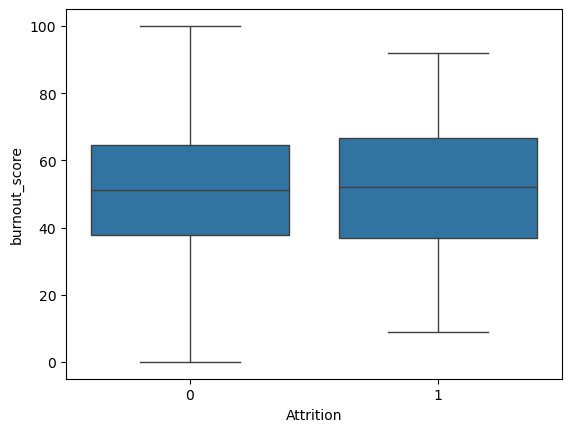

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Attrition', y='burnout_score', data=df)
plt.show()

In [8]:
df.groupby('Attrition')[[
    'work_hours_per_week',
    'meetings_per_week',
    'engagement_score',
    'leave_days_last_3_months'
]].mean()

,work_hours_per_week,meetings_per_week,engagement_score,leave_days_last_3_months
Attrition,,,,
0,50.141119,14.682887,5.591241,7.297648
1,50.248945,14.654008,5.286920,7.502110


In [9]:
import numpy as np

df.loc[df['Attrition'] == 1, 'work_hours_per_week'] += np.random.randint(5, 15, size=sum(df['Attrition']==1))

df.loc[df['Attrition'] == 1, 'meetings_per_week'] += np.random.randint(3, 10, size=sum(df['Attrition']==1))

df.loc[df['Attrition'] == 1, 'engagement_score'] -= np.random.randint(2, 5, size=sum(df['Attrition']==1))
df['engagement_score'] = df['engagement_score'].clip(lower=1)

df.loc[df['Attrition'] == 1, 'leave_days_last_3_months'] += np.random.randint(2, 6, size=sum(df['Attrition']==1))

In [10]:
df['burnout_score'] = (
    0.3 * df['work_hours_per_week'] +
    0.25 * df['meetings_per_week'] +
    0.2 * df['leave_days_last_3_months'] +
    0.25 * (10 - df['engagement_score'])
)

df['burnout_score'] = 100 * (df['burnout_score'] - df['burnout_score'].min()) / (df['burnout_score'].max() - df['burnout_score'].min())

In [11]:
df.groupby('Attrition')['burnout_score'].mean()

Attrition
0    39.801653
1    65.081612
Name: burnout_score, dtype: float64

In [12]:
X = df[[
    'work_hours_per_week',
    'meetings_per_week',
    'engagement_score',
    'leave_days_last_3_months',
    'burnout_score'
]]

y = df['Attrition']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [15]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [16]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9251700680272109
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       255
           1       0.72      0.72      0.72        39

    accuracy                           0.93       294
   macro avg       0.84      0.84      0.84       294
weighted avg       0.93      0.93      0.93       294



In [17]:
df['annual_salary'] = df['MonthlyIncome'] * 12

In [18]:
df['attrition_probability'] = model.predict_proba(X)[:,1]

In [19]:
df['revenue_at_risk'] = df['attrition_probability'] * df['annual_salary']

In [20]:
def segment(row):
    if row['attrition_probability'] > 0.7 and row['burnout_score'] > 70:
        return "Critical"
    elif row['burnout_score'] > 60:
        return "Overworked"
    elif row['attrition_probability'] > 0.5:
        return "Flight Risk"
    else:
        return "Low Risk"

df['risk_category'] = df.apply(segment, axis=1)

In [21]:
def action(cat):
    if cat == "Critical":
        return "Immediate HR intervention"
    elif cat == "Overworked":
        return "Reduce workload"
    elif cat == "Flight Risk":
        return "Retention offer"
    else:
        return "Monitor"

df['recommended_action'] = df['risk_category'].apply(action)

In [22]:
required = [
    'burnout_score','attrition_probability','annual_salary',
    'revenue_at_risk','risk_category','recommended_action'
]
print([c for c in required if c not in df.columns])

[]


In [23]:
print(df['burnout_score'].min(), df['burnout_score'].max())      # expect 0–100
print(df['attrition_probability'].min(), df['attrition_probability'].max())  # expect 0–1
print((df['annual_salary'] > 0).all())                           # True
print((df['revenue_at_risk'] >= 0).all())                        # True

0.0 100.0
8.430835650637894e-05 0.9920700548382594
True
True


In [24]:
print(df.groupby('Attrition')['burnout_score'].mean())
print(df.groupby('Attrition')['attrition_probability'].mean())

Attrition
0    39.801653
1    65.081612
Name: burnout_score, dtype: float64
Attrition
0    0.096360
1    0.555619
Name: attrition_probability, dtype: float64


In [25]:
print(df['risk_category'].value_counts())

risk_category
Low Risk       1204
Overworked      166
Critical         87
Flight Risk      13
Name: count, dtype: int64


In [26]:
print(df.groupby('risk_category')['recommended_action'].unique())

risk_category
Critical       [Immediate HR intervention]
Flight Risk              [Retention offer]
Low Risk                         [Monitor]
Overworked               [Reduce workload]
Name: recommended_action, dtype: object


In [27]:
df.sort_values('revenue_at_risk', ascending=False)[
    ['EmployeeNumber','attrition_probability','annual_salary','revenue_at_risk','risk_category']
].head(10)

,EmployeeNumber,attrition_probability,annual_salary,revenue_at_risk,risk_category
45,58,0.983533,234540,230677.844422,Critical
749,1038,0.873030,238140,207903.290460,Critical
568,787,0.863684,238308,205822.854100,Critical
716,999,0.787044,233028,183403.253727,Overworked
894,1250,0.827101,213348,176460.312130,Critical
975,1372,0.961916,164340,158081.241597,Critical
435,582,0.893989,163320,146006.315254,Critical
770,1069,0.605347,235524,142573.685236,Overworked
1284,1800,0.820159,161568,132511.402614,Overworked
913,1277,0.566662,225888,128002.113907,Flight Risk


In [28]:
print(df[['burnout_score','attrition_probability','revenue_at_risk']].corr())

                       burnout_score  attrition_probability  revenue_at_risk
burnout_score               1.000000               0.816320         0.605116
attrition_probability       0.816320               1.000000         0.735382
revenue_at_risk             0.605116               0.735382         1.000000


In [29]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')